In [18]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error ,r2_score
from sklearn.model_selection import train_test_split
import pandas as pd

In [2]:
insurance_data = pd.read_csv("insurance.csv")
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [20]:
# Features (X) and target (y)
X = insurance_data.drop(columns=["charges"])
y = insurance_data["charges"]

# One-Hot Encode 'region' (avoid dummy variable trap)
X = pd.get_dummies(
    X,
    columns=["region"],
    drop_first=True,
    dtype=int
)

# Binary encoding for categorical features
X["sex"] = X["sex"].map({"female": 1, "male": 0})
X["smoker"] = X["smoker"].map({"yes": 1, "no": 0})

# Feature Engineering: interaction terms
# Capture how smoking impacts charges across age and BMI
X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]

In [21]:
# Split data into training and testing sets
# 80% train, 20% test | random_state=42 for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
lasso_model   = Lasso(alpha = 0.5)
lasso_model.fit(X_train , y_train)

y_pred = lasso_model.predict(X_test)
mse = mean_squared_error(y_test,y_pred)
print("MSE :- " , mse)


MSE :-  20918648.889825605


MSE for alpha = 0.001:-  20922599.87103596
MSE for alpha = 0.1:-  20921803.698431376
MSE for alpha = 1:-  20914832.63508914
MSE for alpha = 2:-  20908106.779954515
MSE for alpha = 5:-  20890881.000633497
MSE for alpha = 10:-  20872844.794796683
MSE for alpha = 20:-  20877828.53237883
MSE for alpha = 30:-  20937537.133939773
MSE for alpha = 40:-  21046489.29389078
MSE for alpha = 50:-  21196929.8696089
MSE for alpha = 100:-  22423172.686023254


<Axes: >

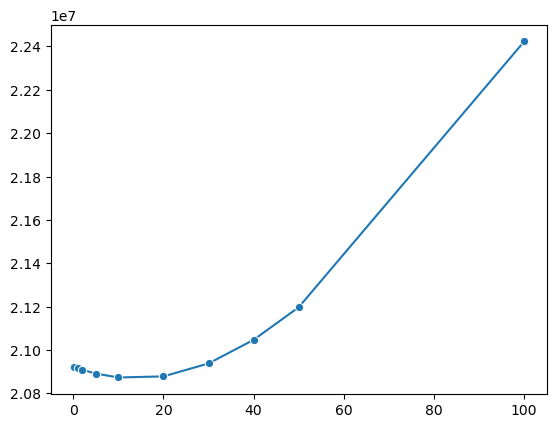

In [23]:
import seaborn as sns
alpha = [0.001,0.1,1,2,5,10,20,30, 40 , 50,100]
mses =[]
for  a in alpha : 
    lasso_model   = Lasso(alpha=a)
    lasso_model.fit(X_train , y_train)

    y_pred = lasso_model.predict(X_test)
    mse = mean_squared_error(y_test,y_pred)
    print(f"MSE for alpha = {a}:- " , mse)
    mses.append(mse)

sns.lineplot(x=alpha , y = mses , marker = "o")

In [27]:
# Lasso CV
from sklearn.linear_model import LassoCV
a = [0.001,0.1,1,2,5,10,20,30, 40 , 50,100]
lasso_cv_model = LassoCV(
    alphas = a , 
    cv = 5 ,
    max_iter = 1000,
    random_state = 42   
)
lasso_cv_model.fit(X_train,y_train)
print("best alpha : "  , lasso_cv_model.alpha_)
y_pred = lasso_cv_model.predict(X_test)
mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print("mse:- " , mse)
print("r2 :- " , r2)

best alpha :  0.001
mse:-  22423172.686023254
r2 :-  0.8652317499151699
